--- Estados ordenados pelo IDH de 2024 ---
   Sigla            Estado   2024
6     DF  Distrito Federal  0.866
25    SP         São Paulo  0.838
23    SC    Santa Catarina  0.833
17    PR            Paraná  0.822
18    RJ    Rio de Janeiro  0.819

Maior melhora: Tocantins (TO) com aumento de 0.428

Nenhum estado teve queda no IDH entre 1991 e 2024.


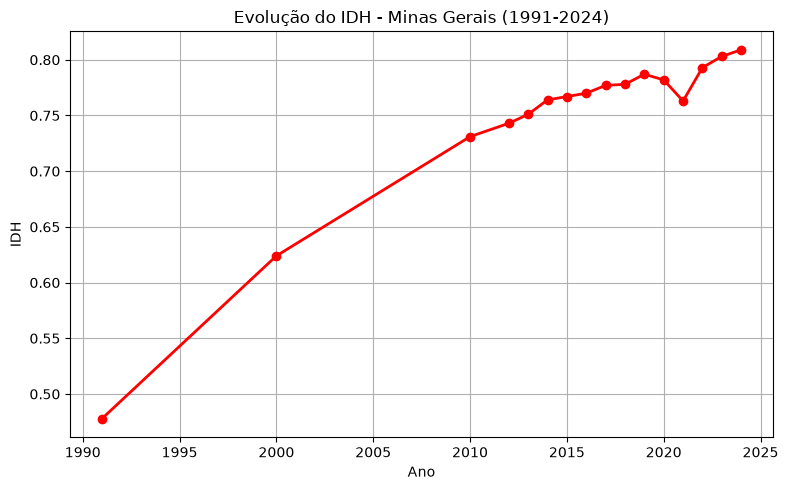

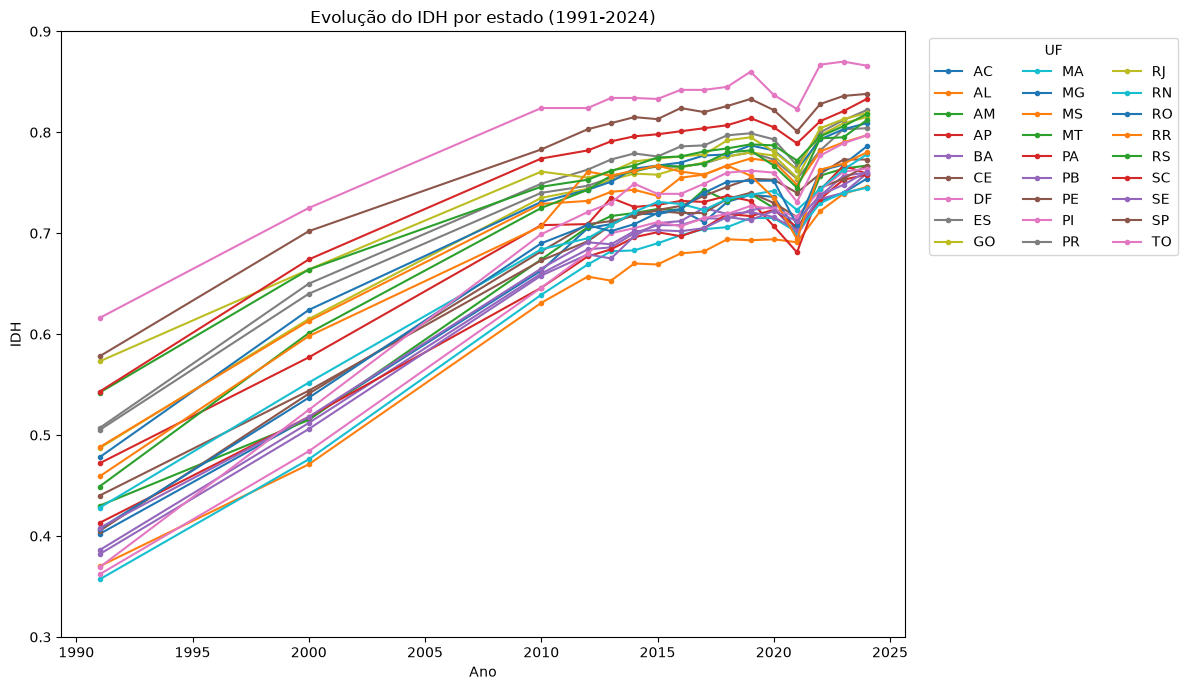

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Tabela4.csv", sep=";", decimal=",", encoding="latin1", header=1)
df = df.dropna(how="all", axis=1)

df_ordenado = df.sort_values(by="2024", ascending=False)
print("--- Estados ordenados pelo IDH de 2024 ---")
print(df_ordenado[["Sigla", "Estado", "2024"]].head())

df["Evolucao_1991_2024"] = df["2024"] - df["1991"]
maior_melhora = df.loc[df["Evolucao_1991_2024"].idxmax()]
print(f"\nMaior melhora: {maior_melhora['Estado']} ({maior_melhora['Sigla']}) com aumento de {maior_melhora['Evolucao_1991_2024']:.3f}")

pioraram = df[df["Evolucao_1991_2024"] < 0]
if pioraram.empty:
    print("\nNenhum estado teve queda no IDH entre 1991 e 2024.")
else:
    print("\nEstados em que o IDH piorou:")
    print(pioraram[["Sigla", "Estado", "Evolucao_1991_2024"]])

anos = [c for c in df.columns if str(c).isdigit()]
id_vars = [c for c in df.columns if c not in anos and c != "Evolucao_1991_2024"]

df_longo = df.melt(
    id_vars=id_vars,
    value_vars=anos,
    var_name="Ano",
    value_name="IDH"
)

df_longo["Ano"] = df_longo["Ano"].astype(int)
df_longo["IDH"] = pd.to_numeric(df_longo["IDH"], errors="coerce")

df_mg = df_longo[df_longo["Sigla"] == "MG"].sort_values("Ano")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(df_mg["Ano"], df_mg["IDH"], marker="o", color="red", linewidth=2, label="MG")
ax.set_title("Evolução do IDH - Minas Gerais (1991-2024)")
ax.set_xlabel("Ano")
ax.set_ylabel("IDH")
ax.grid(True)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 7))

for sigla, grupo in df_longo.groupby("Sigla"):
    grupo = grupo.sort_values("Ano")
    ax.plot(grupo["Ano"], grupo["IDH"], marker="o", markersize=3, linewidth=1.5, label=sigla)

ax.set_title("Evolução do IDH por estado (1991-2024)")
ax.set_xlabel("Ano")
ax.set_ylabel("IDH")
ax.set_ylim(0.3, 0.9)
ax.legend(ncol=3, bbox_to_anchor=(1.02, 1), loc="upper left", title="UF")
fig.tight_layout()
plt.show()